In [1]:
import numpy as np
import pandas as pd
import sys
import os
sys.path.append(os.path.abspath('..'))
import matplotlib.pyplot as plt
from scripts import nodes as n
from scripts import elements as e
from scripts import material_params as mat
from scipy.linalg import eigh
import plotly.graph_objects as go
from scripts import FDD as fdd
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

In [2]:
data_43 = pd.read_csv('csv_files/fem_inversion_success_3D_43.csv')
data_42 = pd.read_csv('csv_files/fem_inversion_success_2D_42.csv')
data_33 = pd.read_csv('csv_files/fem_inversion_success_3D_33.csv')
data_32 = pd.read_csv('csv_files/fem_inversion_success_2D_32.csv')
data_22 = pd.read_csv('csv_files/fem_inversion_success_2D_22.csv')
data_43_2 = pd.read_csv('csv_files/fem_inversion_success_3D_2_43.csv')
data_33_2 = pd.read_csv('csv_files/fem_inversion_success_3D_2_33.csv')

## **3D parameter space**

In [3]:
param_space = np.load("param_spaces/param_space.npy")
param_space_eigvecs = np.load("param_spaces/param_space_eigvecs.npy")

N3 = param_space.shape[0]
DOF = param_space_eigvecs.shape[3]

kf_min3, kf_max3 = 5e6, 5e7
Iy_min3, Iy_max3 = 100, 2000
kl_min3, kl_max3 = 0.2e10, 1e10

kf_vals3 = np.linspace(kf_min3, kf_max3, N3)
Iy_vals3 = np.linspace(Iy_min3, Iy_max3, N3)
kl_vals3 = np.linspace(kl_min3, kl_max3, N3)


## **2D parameter space**

In [4]:
param_space2D = np.load("param_spaces/param_space2D.npy")
param_space_eigvecs2D = np.load("param_spaces/param_space_eigvecs2D.npy")

N2 = param_space2D.shape[0]
DOF = param_space_eigvecs2D.shape[2]

kf_min2, kf_max2 = 5e6, 5e7
Iy_min2, Iy_max2 = 100, 2000

kf_vals2 = np.linspace(kf_min2, kf_max2, N2)
Iy_vals2 = np.linspace(Iy_min2, Iy_max2, N2)

## **The second 3D parameter space**

In [5]:
param_space3D_2 = np.load("param_spaces/param_space3D_2.npy")
param_space_eigvecs3D_2 = np.load("param_spaces/param_space_eigvecs3D_2.npy")

N3_2 = param_space3D_2.shape[0]
DOF = param_space_eigvecs3D_2.shape[3]

kf_min3_2, kf_max3_2 = 5e6, 5e7
Iy_min3_2, Iy_max3_2 = 100, 2000
Iy_wall_min3_2, Iy_wall_max3_2 = 100, 2000

kf_vals3_2 = np.linspace(kf_min3_2, kf_max3_2, N3_2)
Iy_vals3_2 = np.linspace(Iy_min3_2, Iy_max3_2, N3_2)
Iy_wall_vals3_2 = np.linspace(Iy_wall_min3_2, Iy_wall_max3_2, N3_2)

## **3D plots (Only histogram)**

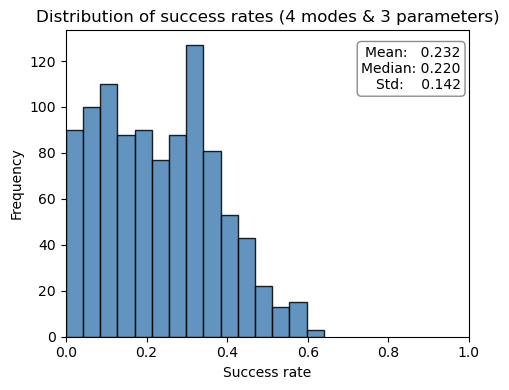

In [6]:
values = data_43["success_rate"].dropna()

mean_val = np.mean(values)
median_val = np.median(values)
std_val = np.std(values)

plt.figure(figsize=(5, 4))

plt.hist(
    values,
    bins="fd",
    color="steelblue",
    edgecolor="black",
    alpha=0.85
)

plt.xlabel("Success rate")
plt.ylabel("Frequency")
plt.title("Distribution of success rates (4 modes & 3 parameters)")

textstr = (
    f"Mean:   {mean_val:.3f}\n"
    f"Median: {median_val:.3f}\n"
    f"Std:    {std_val:.3f}"
)

plt.gca().text(
    0.98, 0.95,
    textstr,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    horizontalalignment="right",
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray", alpha=0.9)
)

plt.xlim(0,1)
plt.tight_layout()
plt.show()



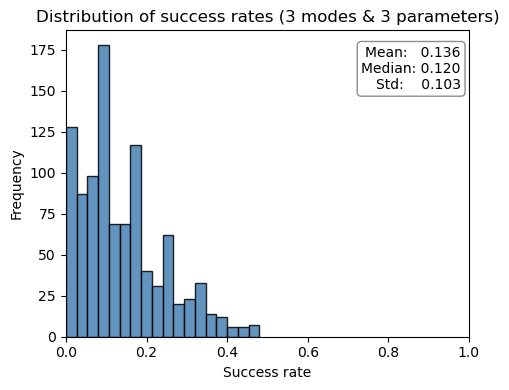

In [7]:
values = data_33["success_rate"].dropna()

mean_val = np.mean(values)
median_val = np.median(values)
std_val = np.std(values)

plt.figure(figsize=(5, 4))

plt.hist(
    values,
    bins="fd",
    color="steelblue",
    edgecolor="black",
    alpha=0.85
)

plt.xlabel("Success rate")
plt.ylabel("Frequency")
plt.title("Distribution of success rates (3 modes & 3 parameters)")

textstr = (
    f"Mean:   {mean_val:.3f}\n"
    f"Median: {median_val:.3f}\n"
    f"Std:    {std_val:.3f}"
)

plt.gca().text(
    0.98, 0.95,
    textstr,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    horizontalalignment="right",
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray", alpha=0.9)
)
plt.xlim(0,1)
plt.tight_layout()
plt.show()

## **2D plots (histograms and heat maps)**

C:\Users\alami\AppData\Local\Temp\ipykernel_11688\3295839873.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(frameon=False)


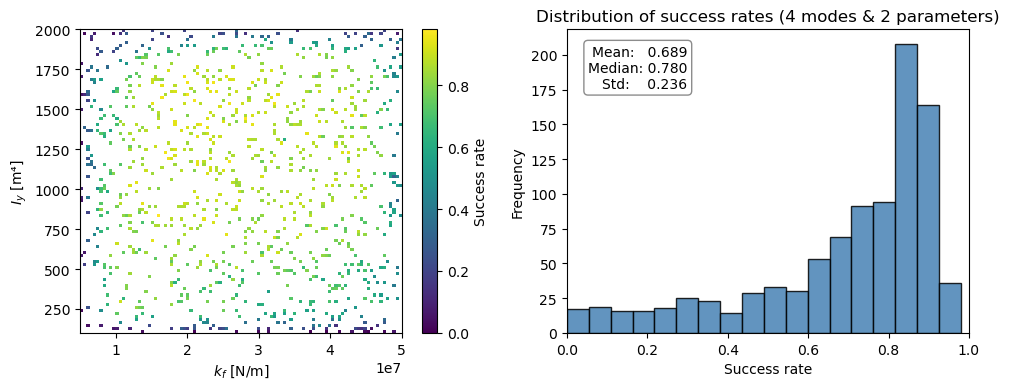

In [8]:
import numpy as np
import matplotlib.pyplot as plt

success_grid = np.full((N2, N2), np.nan)

for _, row in data_42.iterrows():
    success_grid[int(row["i"]), int(row["j"])] = row["success_rate"]

valid_values = success_grid[~np.isnan(success_grid)]

mean_val = np.mean(valid_values)
median_val = np.median(valid_values)
std_val = np.std(valid_values)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im = axes[0].imshow(
    success_grid,
    origin="lower",
    aspect="auto",
    extent=[kf_min2, kf_max2, Iy_min2, Iy_max2],
    cmap="viridis"
)

axes[0].set_xlabel(r"$k_f$ [N/m]")
axes[0].set_ylabel(r"$I_y$ [m⁴]")

cbar = fig.colorbar(im, ax=axes[0])
cbar.set_label("Success rate")

axes[1].hist(
    valid_values,
    bins="fd",
    color="steelblue",
    edgecolor="black",
    alpha=0.85
)

axes[1].set_xlabel("Success rate")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Distribution of success rates (4 modes & 2 parameters)")
axes[1].legend(frameon=False)
axes[1].set_xlim(0, 1)

textstr = (
    f"Mean:   {mean_val:.3f}\n"
    f"Median: {median_val:.3f}\n"
    f"Std:    {std_val:.3f}"
)

axes[1].text(
    0.3, 0.95,
    textstr,
    transform=axes[1].transAxes,
    fontsize=10,
    verticalalignment="top",
    horizontalalignment="right",
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray", alpha=0.9)
)

fig.patch.set_facecolor("white")
axes[0].set_facecolor("white")
axes[1].set_facecolor("white")

plt.tight_layout()
plt.show()

C:\Users\alami\AppData\Local\Temp\ipykernel_11688\398355613.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(frameon=False)


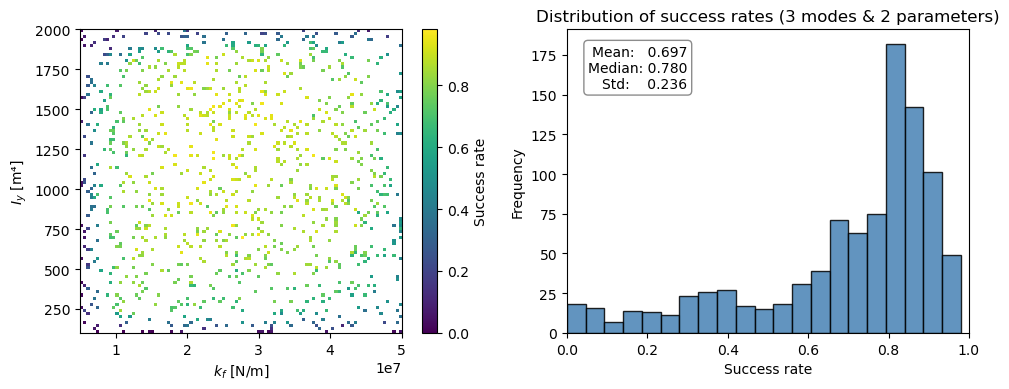

In [9]:
import numpy as np
import matplotlib.pyplot as plt

success_grid = np.full((N2, N2), np.nan)

for _, row in data_32.iterrows():
    success_grid[int(row["i"]), int(row["j"])] = row["success_rate"]

valid_values = success_grid[~np.isnan(success_grid)]

mean_val = np.mean(valid_values)
median_val = np.median(valid_values)
std_val = np.std(valid_values)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im = axes[0].imshow(
    success_grid,
    origin="lower",
    aspect="auto",
    extent=[kf_min2, kf_max2, Iy_min2, Iy_max2],
    cmap="viridis"
)

axes[0].set_xlabel(r"$k_f$ [N/m]")
axes[0].set_ylabel(r"$I_y$ [m⁴]")

cbar = fig.colorbar(im, ax=axes[0])
cbar.set_label("Success rate")

axes[1].hist(
    valid_values,
    bins="fd",
    color="steelblue",
    edgecolor="black",
    alpha=0.85
)

axes[1].set_xlabel("Success rate")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Distribution of success rates (3 modes & 2 parameters)")
axes[1].legend(frameon=False)
axes[1].set_xlim(0, 1)

textstr = (
    f"Mean:   {mean_val:.3f}\n"
    f"Median: {median_val:.3f}\n"
    f"Std:    {std_val:.3f}"
)

axes[1].text(
    0.3, 0.95,
    textstr,
    transform=axes[1].transAxes,
    fontsize=10,
    verticalalignment="top",
    horizontalalignment="right",
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray", alpha=0.9)
)

fig.patch.set_facecolor("white")
axes[0].set_facecolor("white")
axes[1].set_facecolor("white")

plt.tight_layout()
plt.show()

C:\Users\alami\AppData\Local\Temp\ipykernel_11688\2507071685.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(frameon=False)


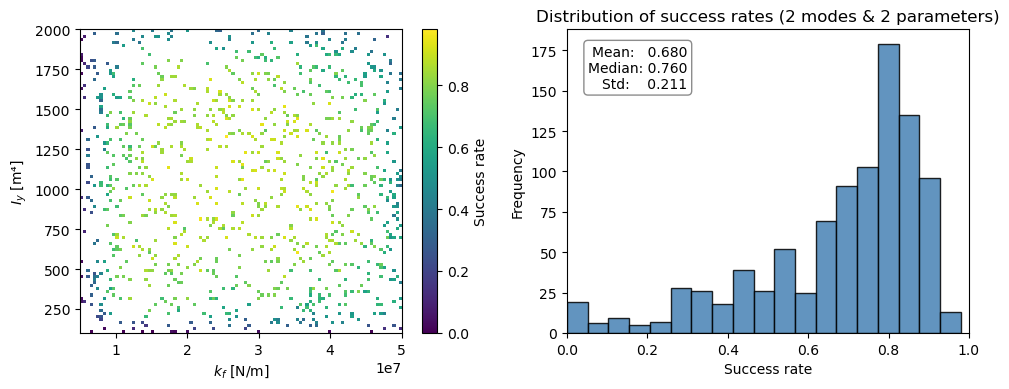

In [10]:
success_grid = np.full((N2, N2), np.nan)

for _, row in data_22.iterrows():
    success_grid[int(row["i"]), int(row["j"])] = row["success_rate"]

valid_values = success_grid[~np.isnan(success_grid)]

mean_val = np.mean(valid_values)
median_val = np.median(valid_values)
std_val = np.std(valid_values)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im = axes[0].imshow(
    success_grid,
    origin="lower",
    aspect="auto",
    extent=[kf_min2, kf_max2, Iy_min2, Iy_max2],
    cmap="viridis"
)

axes[0].set_xlabel(r"$k_f$ [N/m]")
axes[0].set_ylabel(r"$I_y$ [m⁴]")

cbar = fig.colorbar(im, ax=axes[0])
cbar.set_label("Success rate")

axes[1].hist(
    valid_values,
    bins="fd",
    color="steelblue",
    edgecolor="black",
    alpha=0.85
)


axes[1].set_xlabel("Success rate")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Distribution of success rates (2 modes & 2 parameters)")
axes[1].legend(frameon=False)
axes[1].set_xlim(0, 1)

textstr = (
    f"Mean:   {mean_val:.3f}\n"
    f"Median: {median_val:.3f}\n"
    f"Std:    {std_val:.3f}"
)

axes[1].text(
    0.3, 0.95,
    textstr,
    transform=axes[1].transAxes,
    fontsize=10,
    verticalalignment="top",
    horizontalalignment="right",
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray", alpha=0.9)
)


fig.patch.set_facecolor("white")
axes[0].set_facecolor("white")
axes[1].set_facecolor("white")

plt.tight_layout()
plt.show()

## **3D plots new (Only histogram)**

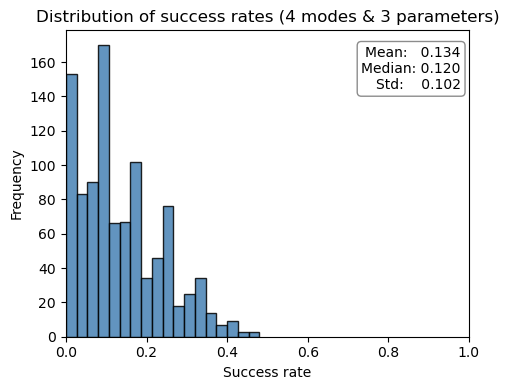

In [11]:
values = data_43_2["success_rate"].dropna()

mean_val = np.mean(values)
median_val = np.median(values)
std_val = np.std(values)

plt.figure(figsize=(5, 4))

plt.hist(
    values,
    bins="fd",
    color="steelblue",
    edgecolor="black",
    alpha=0.85
)

plt.xlabel("Success rate")
plt.ylabel("Frequency")
plt.title("Distribution of success rates (4 modes & 3 parameters)")

textstr = (
    f"Mean:   {mean_val:.3f}\n"
    f"Median: {median_val:.3f}\n"
    f"Std:    {std_val:.3f}"
)

plt.gca().text(
    0.98, 0.95,
    textstr,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    horizontalalignment="right",
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray", alpha=0.9)
)

plt.xlim(0,1)
plt.tight_layout()
plt.show()



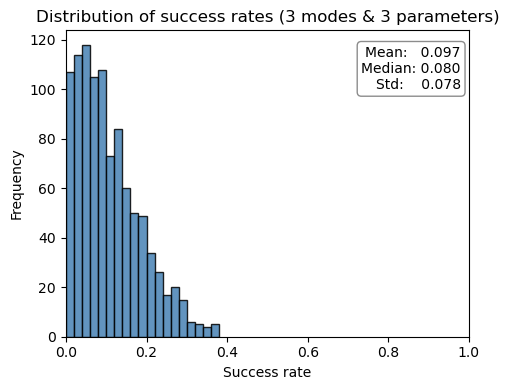

In [12]:
values = data_33_2["success_rate"].dropna()

mean_val = np.mean(values)
median_val = np.median(values)
std_val = np.std(values)

plt.figure(figsize=(5, 4))

plt.hist(
    values,
    bins="fd",
    color="steelblue",
    edgecolor="black",
    alpha=0.85
)

plt.xlabel("Success rate")
plt.ylabel("Frequency")
plt.title("Distribution of success rates (3 modes & 3 parameters)")

textstr = (
    f"Mean:   {mean_val:.3f}\n"
    f"Median: {median_val:.3f}\n"
    f"Std:    {std_val:.3f}"
)

plt.gca().text(
    0.98, 0.95,
    textstr,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    horizontalalignment="right",
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray", alpha=0.9)
)

plt.xlim(0,1)
plt.tight_layout()
plt.show()